# Modelo de Hopfield como memoria asociativa

## Física Computacional  
**Universidad de Granada**

---

### Autor  
Mario Hernández Cuéllar

### Fecha  
29 Abril 2026

---

## Introducción

En este trabajo se estudia el comportamiento de una red de Hopfield como sistema de memoria asociativa, utilizando simulaciones Monte Carlo. El objetivo principal es analizar la capacidad de la red para almacenar y recuperar patrones a partir de condiciones iniciales incompletas o ruidosas. Estudiando la influencia de la temperatura, el número de patrones almacenados y la estructura de los mismos en la capacidad de recuperación de la red.

Se consideran tanto patrones aleatorios como patrones estructurados (dígitos del 0 al 9), con el fin de analizar las limitaciones del modelo en situaciones más realistas. Asimismo, se estima la capacidad crítica de almacenamiento de la red mediante el cálculo del parámetro $\alpha_c$.

## 1. Fundamento teórico

El modelo de Hopfield es un modelo de red neuronal recurrente que actúa como una **memoria asociativa**, capaz de almacenar un conjunto de configuraciones (patrones) y recuperarlas a partir de estados iniciales incompletos o perturbados. Cada neurona de la red puede encontrarse en dos estados, activo o inactivo, y el sistema evoluciona dinámicamente hacia configuraciones de mínima energía.

En este trabajo se ha considerado una red bidimensional de $N \times N$ neuronas, donde cada neurona $s_{i,j}$ toma valores binarios. La dinámica del sistema viene gobernada por un **Hamiltoniano** de la forma:

$$
H(s) = -\frac{1}{2} \sum_{i,j,k,l} \omega_{ij,kl} \, s_{i,j} s_{k,l} + \sum_{i,j} \theta_{i,j} \, s_{i,j}
$$

donde $\omega_{ij,kl}$ representa los **pesos sinápticos** entre neuronas, y $\theta_{i,j}$ es el umbral de activación. Los patrones almacenados en la red corresponden a mínimos de este Hamiltoniano, por lo que la evolución del sistema tiende a recuperar dichas configuraciones.

Los pesos sinápticos se construyen a partir de un conjunto de patrones previamente almacenados $\{ \xi^\mu \}$, mediante una regla tipo Hebb modificada:

$$
\omega_{ij,kl} = \frac{1}{N^2} \sum_{\mu} \left( \xi^\mu_{i,j} - a^\mu \right)\left( \xi^\mu_{k,l} - a^\mu \right)
$$

donde $a^\mu$ representa la actividad media del patrón. Esta formulación, basada en el trabajo de Amit, Gutfreund y Sompolinsky, permite almacenar patrones con distinto nivel de actividad, evitando correlaciones no deseadas entre ellos.

La evolución temporal del sistema se simula mediante el **algoritmo de Metrópolis**, que introduce efectos térmicos controlados por la temperatura $T$. En cada paso, se propone un cambio en el estado de una neurona y se acepta con probabilidad:

$$
p = \min\left(1, e^{-\Delta H / T} \right)
$$

donde $\Delta H$ es la variación de energía asociada al cambio. Este procedimiento permite al sistema explorar el espacio de configuraciones y converger hacia estados estables.

Para cuantificar la capacidad de recuperación de la memoria, se introduce el **solapamiento** entre el estado actual de la red y un patrón almacenado:

$$
m^\mu = \frac{1}{N^2 a^\mu (1 - a^\mu)} \sum_{i,j} \left( \xi^\mu_{i,j} - a^\mu \right)\left( s_{i,j} - a^\mu \right)
$$

Este parámetro toma valores entre $-1$ y $1$, indicando respectivamente la recuperación del antipatrón, ausencia de correlación o recuperación perfecta del patrón.

Finalmente, cabe destacar que el modelo presenta limitaciones como la aparición de **estados espurios** y una capacidad finita de almacenamiento. Tal como se discute en el artículo de referencia, la introducción de patrones con actividad no equilibrada y modificaciones en la dinámica permiten mejorar el comportamiento de la red.

## 2. Herramientas empleadas

Para la realización de este trabajo se han utilizado distintas herramientas tanto para el desarrollo del código como para la elaboración del informe.

Por un lado, se ha empleado el lenguaje de programación **Python**, junto con las librerías `numpy` para el cálculo numérico y `matplotlib` para la representación gráfica de resultados. La implementación y organización del código se ha realizado en **Google Colab**, lo que permite estructurar el trabajo en bloques, combinar código con explicaciones teóricas y garantizar la reproducibilidad de los resultados.

Además, se ha hecho uso de herramientas de inteligencia artificial como apoyo en el desarrollo del trabajo, especialmente en la comprensión del modelo teórico y en la estructuración del código.

---

### 2.1 Uso de herramientas de inteligencia artificial

Para la realización de este trabajo se ha utilizado **ChatGPT** como herramienta de apoyo en distintas fases del proceso.

En primer lugar, se proporcionó a la herramienta el **enunciado completo del ejercicio** junto con el articulo **Information storage in neural networks with low levels of activity**(vease la bibliografía), con el objetivo de comprender en profundidad el modelo de Hopfield y sus extensiones para patrones con actividad sesgada. A partir de esto, se solicitó una explicación detallada de los conceptos físicos involucrados, incluyendo el significado del Hamiltoniano, la regla de Hebb modificada y el papel del solapamiento como medida de recuperación de memoria.

Posteriormente, se utilizó la herramienta como guía para determinar la **mejor forma de abordar la implementación computacional**, solicitando recomendaciones sobre cómo estructurar el código para que fuese claro, modular y coherente con el contenido teórico del problema. En este sentido, se estableció desde el inicio que el código debía:

- ser **modular**, separando claramente cada parte del modelo (generación de patrones, cálculo de pesos, dinámica, etc.),
- ser **comprensible**, evitando implementaciones innecesariamente complejas,
- y reflejar de forma fiel las expresiones teóricas utilizadas.

A lo largo del desarrollo, se fueron planteando dudas concretas sobre la implementación, el uso de determinadas estructuras de programación y la organización del trabajo en un entorno tipo **notebook**. En particular, se utilizó la herramienta para adaptar el código a un formato adecuado para **Google Colab**, estructurándolo en bloques que alternan explicación teórica y código ejecutable.

## 3. Procedimiento computacional

El programa se ha dividido en bloques para separar claramente la construcción del modelo, la dinámica de Metrópolis y el análisis de resultados. De esta forma, el notebook puede ejecutarse de arriba a abajo, manteniendo una explicación clara de cada parte del código.

### 3.1. Importación de librerías y generador aleatorio

En primer lugar se importan las librerías necesarias para la simulación. Se utiliza `numpy` para trabajar con matrices y operaciones numéricas, y `matplotlib.pyplot` para representar gráficamente los resultados.

También se define un generador de números aleatorios mediante `np.random.default_rng()`. Esto permite fijar una semilla y obtener simulaciones reproducibles.

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def crear_rng(seed=None):
    """
    Crea un generador moderno de números aleatorios de NumPy.

    Usamos np.random.default_rng(), que permite controlar la
    reproducibilidad de la simulación mediante una semilla.
    """
    return np.random.default_rng(seed)

### 3.2. Generación y deformación de patrones

En este bloque se generan los patrones que la red debe almacenar. Cada patrón es una matriz de tamaño $N \times N$ cuyos valores son binarios ($0$ o $1$), representando neuronas inactivas o activas, respectivamente.

La probabilidad de que una neurona esté activa viene dada por el parámetro `prob_activa`. Esto permite trabajar con redes de baja actividad, en línea con modelos más realistas donde la mayoría de neuronas están inactivas.

Además, se introduce una función para deformar un patrón, modificando aleatoriamente una fracción de sus neuronas. Esto permite estudiar la capacidad de la red para recuperar un patrón a partir de una versión perturbada, que es uno de los objetivos principales del modelo de Hopfield.

In [5]:
# ============================================================
# 2. PATRONES
# ============================================================

def crear_patron_aleatorio(N, prob_activa=0.3, rng=None):
    """
    Crea un patrón aleatorio N x N con valores 0 y 1.

    prob_activa:
        Probabilidad de que una neurona esté activa (valor 1).
    """
    if rng is None:
        rng = crear_rng()

    patron = rng.random((N, N)) < prob_activa
    return patron.astype(int)


def deformar_patron(patron, fraccion_ruido=0.2, rng=None):
    """
    Deforma un patrón cambiando una fracción de sus neuronas.

    Si una neurona vale 1 pasa a 0.
    Si una neurona vale 0 pasa a 1.
    """
    if rng is None:
        rng = crear_rng()

    patron_deformado = patron.copy()
    N = patron.shape[0]

    numero_neuronas = N * N
    numero_cambios = int(fraccion_ruido * numero_neuronas)

    indices = rng.choice(numero_neuronas, size=numero_cambios, replace=False)

    patron_plano = patron_deformado.ravel()
    patron_plano[indices] = 1 - patron_plano[indices]

    return patron_deformado


def calcular_bias(patrones):
    """
    Calcula el bias medio a de los patrones.

    patrones debe tener forma (P, N, N)
    donde P es el número de patrones.
    """
    return np.mean(patrones)

### 3.3. Cálculo de los pesos sinápticos

En este bloque se construye la matriz de pesos sinápticos de la red de Hopfield a partir de los patrones previamente generados.

Cada patrón bidimensional de tamaño $N \times N$ se reescribe como un vector de longitud $M = N^2$, de forma que la red se interpreta como un sistema completamente conectado de $M$ neuronas.

Los pesos se calculan mediante una versión modificada de la regla de Hebb:

$$
\omega_{ij} =
\frac{1}{a(1-a)M}
\sum_{\mu}
(\xi_i^\mu - a)(\xi_j^\mu - a),
$$

donde $a$ es la actividad media de los patrones.

La resta del término $a$ permite centrar los patrones y eliminar el efecto de correlaciones triviales debidas al sesgo de activación. Este tipo de corrección es fundamental cuando se trabaja con patrones de baja actividad, tal como se discute en modelos extendidos del modelo de Hopfield.

Finalmente, se eliminan las autoconexiones imponiendo $\omega_{ii} = 0$, ya que una neurona no puede interactuar consigo misma.

In [6]:
# ============================================================
# 3. PESOS SINÁPTICOS
# ============================================================

def calcular_pesos(patrones):
    """
    Calcula la matriz de pesos de la red de Hopfield modificada.

    Los patrones tienen valores 0 y 1.

    Fórmula usada:

        w_ij = 1 / [a(1-a) M] * sum_mu (xi_i^mu - a)(xi_j^mu - a)

    donde:
        M = N*N = número total de neuronas.
        a = actividad media o bias.
    """
    patrones = np.array(patrones)

    P, N, _ = patrones.shape
    M = N * N

    a = calcular_bias(patrones)

    if a == 0 or a == 1:
        raise ValueError("El bias no puede ser 0 ni 1, porque aparece en el denominador.")

    # Pasamos de matrices (N,N) a vectores (M)
    patrones_planos = patrones.reshape(P, M)

    # Centramos los patrones restando el bias
    patrones_centrados = patrones_planos - a

    # Regla de Hebb modificada
    pesos = (patrones_centrados.T @ patrones_centrados) / (a * (1 - a) * M)

    # Eliminamos autoconexiones
    np.fill_diagonal(pesos, 0)

    return pesos, a

### 3.4. Energía del sistema y dinámica de Metrópolis

Una vez definidos los pesos sinápticos, es necesario definir la energía del sistema y su dinámica temporal.

El comportamiento de la red viene gobernado por el Hamiltoniano:

$$
H(s) =
-\frac{1}{2}
\sum_{i,j}
\omega_{ij} s_i s_j
+
\sum_i
\theta_i s_i,
$$

donde los umbrales se definen como:

$$
\theta_i = \frac{1}{2} \sum_j \omega_{ij}.
$$

Los patrones almacenados corresponden a mínimos de esta energía, por lo que la evolución del sistema tiende a configuraciones estables cercanas a dichos patrones.

La dinámica se implementa mediante el algoritmo de Metrópolis. En cada paso se selecciona una neurona al azar y se propone cambiar su estado:

$$
s_i \rightarrow 1 - s_i.
$$

El cambio se acepta siempre si disminuye la energía ($\Delta H \leq 0$). Si aumenta la energía, se acepta con probabilidad:

$$
p = \min\left(1, e^{-\Delta H / T} \right).
$$

De este modo, la temperatura $T$ introduce fluctuaciones térmicas que permiten al sistema escapar de mínimos locales.

Para mejorar la eficiencia computacional, no se recalcula la energía completa en cada intento, sino únicamente la variación de energía $\Delta H$ asociada al cambio de una sola neurona.

In [7]:
# ============================================================
# 4. ENERGÍA Y DINÁMICA DE METROPOLIS
# ============================================================

def calcular_umbrales(pesos):
    """
    Calcula los umbrales theta_i.

    Según el modelo:
        theta_i = 1/2 * sum_j w_ij
    """
    return 0.5 * np.sum(pesos, axis=1)


def calcular_energia(estado, pesos, umbrales):
    """
    Calcula la energía de una configuración.

    H = -1/2 sum_ij w_ij s_i s_j + sum_i theta_i s_i
    """
    s = estado.ravel()

    energia_interaccion = -0.5 * s @ pesos @ s
    energia_umbral = np.sum(umbrales * s)

    return energia_interaccion + energia_umbral


def calcular_delta_energia(estado, indice, pesos, umbrales):
    """
    Calcula Delta H al cambiar una única neurona.
    """
    s = estado.ravel()

    valor_actual = s[indice]
    valor_nuevo = 1 - valor_actual

    delta_s = valor_nuevo - valor_actual

    # Campo local
    campo = np.dot(pesos[indice], s)

    delta_H = -delta_s * campo + umbrales[indice] * delta_s

    return delta_H


def paso_metropolis(estado, pesos, umbrales, T, rng=None):
    """
    Realiza un intento de cambio usando Metrópolis.
    """
    if rng is None:
        rng = crear_rng()

    N = estado.shape[0]
    M = N * N

    indice = rng.integers(0, M)

    delta_H = calcular_delta_energia(estado, indice, pesos, umbrales)

    if delta_H <= 0:
        aceptar = True
    else:
        probabilidad = np.exp(-delta_H / T)
        aceptar = rng.random() < probabilidad

    if aceptar:
        estado.ravel()[indice] = 1 - estado.ravel()[indice]

    return aceptar

### 3.5. Evolución temporal: pasos Monte Carlo

Una vez definida la dinámica de Metrópolis para una sola neurona, es necesario extenderla a la evolución completa del sistema.

Se define un **paso Monte Carlo (MC)** como $N^2$ intentos de cambio, de forma que, en promedio, cada neurona tiene una oportunidad de actualizar su estado. Esta definición es estándar en simulaciones tipo Ising y permite comparar tiempos entre sistemas de distinto tamaño.

Durante la evolución, el sistema va explorando el espacio de configuraciones y tiende a estados de menor energía. Para caracterizar esta evolución, se registran:

- la energía del sistema en cada paso,
- la fracción de cambios aceptados (relacionada con la temperatura),
- y posteriormente el solapamiento con los patrones.

Esto permite analizar si la red converge hacia uno de los patrones almacenados y con qué rapidez lo hace.

In [8]:
# ============================================================
# 5. EVOLUCIÓN MONTE CARLO
# ============================================================

def paso_montecarlo(estado, pesos, umbrales, T, rng=None):
    """
    Realiza un paso Monte Carlo completo.

    Un paso MC equivale a N*N intentos de cambio.
    """
    if rng is None:
        rng = crear_rng()

    N = estado.shape[0]
    M = N * N

    aceptados = 0

    for _ in range(M):
        if paso_metropolis(estado, pesos, umbrales, T, rng):
            aceptados += 1

    fraccion_aceptados = aceptados / M

    return fraccion_aceptados


def evolucionar_red(estado_inicial, pesos, umbrales, T, num_pasos_mc, rng=None):
    """
    Evoluciona la red durante varios pasos Monte Carlo.

    Guarda energía y fracción de aceptaciones.
    """
    if rng is None:
        rng = crear_rng()

    estado = estado_inicial.copy()

    energias = []
    aceptaciones = []

    for _ in range(num_pasos_mc):
        fraccion_aceptados = paso_montecarlo(estado, pesos, umbrales, T, rng)

        energia = calcular_energia(estado, pesos, umbrales)

        energias.append(energia)
        aceptaciones.append(fraccion_aceptados)

    return estado, np.array(energias), np.array(aceptaciones)

### 3.6. Cálculo del solapamiento

Para cuantificar la capacidad de la red de recuperar un patrón almacenado, se introduce el **solapamiento** entre el estado actual del sistema y cada uno de los patrones.

El solapamiento con el patrón $\mu$ se define como:

$$
m^\mu(s) =
\frac{1}{N^2 a^\mu (1-a^\mu)}
\sum_{i,j}
(\xi_{i,j}^\mu - a^\mu)(s_{i,j} - a^\mu),
$$

donde $a^\mu$ es la actividad media del patrón.

Este parámetro toma valores en el intervalo $[-1,1]$:

- $m^\mu \approx 1$ → el patrón se ha recuperado correctamente,
- $m^\mu \approx 0$ → no hay correlación,
- $m^\mu \approx -1$ → se obtiene el antipatrón (estado espurio).

Durante la evolución del sistema, se calcula el solapamiento en cada paso Monte Carlo, lo que permite analizar cómo la red se aproxima progresivamente a un patrón almacenado.

In [9]:
# ============================================================
# 6. SOLAPAMIENTO
# ============================================================

def calcular_solapamiento(estado, patron):
    """
    Calcula el solapamiento entre el estado actual y un patrón.
    """
    s = estado.ravel()
    xi = patron.ravel()

    M = len(xi)
    a = np.mean(xi)

    if a == 0 or a == 1:
        raise ValueError("El patrón no puede tener bias 0 ni 1.")

    m = np.sum((xi - a) * (s - a)) / (M * a * (1 - a))

    return m


def calcular_solapamientos(estado, patrones):
    """
    Calcula el solapamiento del estado con todos los patrones.
    """
    return np.array([
        calcular_solapamiento(estado, patron)
        for patron in patrones
    ])


def evolucionar_red_con_solapamiento(
    estado_inicial, pesos, umbrales, patrones, T, num_pasos_mc, rng=None
):
    """
    Evoluciona la red guardando energía, aceptaciones y solapamientos.
    """
    if rng is None:
        rng = crear_rng()

    estado = estado_inicial.copy()

    energias = []
    aceptaciones = []
    solapamientos = []

    # Estado inicial
    energias.append(calcular_energia(estado, pesos, umbrales))
    aceptaciones.append(0)
    solapamientos.append(calcular_solapamientos(estado, patrones))

    for _ in range(num_pasos_mc):
        fraccion_aceptados = paso_montecarlo(estado, pesos, umbrales, T, rng)

        energias.append(calcular_energia(estado, pesos, umbrales))
        aceptaciones.append(fraccion_aceptados)
        solapamientos.append(calcular_solapamientos(estado, patrones))

    return (
        estado,
        np.array(energias),
        np.array(aceptaciones),
        np.array(solapamientos)
    )


def representar_solapamientos(solapamientos):
    """
    Representa el solapamiento en función del tiempo.
    """
    num_pasos = solapamientos.shape[0]
    num_patrones = solapamientos.shape[1]

    tiempos = np.arange(num_pasos)

    plt.figure(figsize=(7, 4))

    for mu in range(num_patrones):
        plt.plot(tiempos, solapamientos[:, mu], marker="o", label=f"Patrón {mu+1}")

    plt.xlabel("Paso Monte Carlo")
    plt.ylabel("Solapamiento")
    plt.title("Solapamiento con los patrones almacenados")
    plt.ylim(-1.05, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

### 3.7. Estudio de la recuperación en función de la temperatura

Uno de los objetivos del ejercicio es analizar cómo afecta la temperatura a la capacidad de la red para recuperar un patrón almacenado.

Para ello, se realiza el siguiente procedimiento:

1. Se selecciona un patrón objetivo.
2. Se genera un estado inicial deformado a partir de dicho patrón.
3. Se evoluciona la red mediante dinámica de Metrópolis durante un número fijo de pasos Monte Carlo.
4. Se mide el solapamiento final con el patrón objetivo.

Este proceso se repite para distintos valores de la temperatura $T$. Además, para cada temperatura se realizan varias repeticiones independientes, con el fin de reducir el efecto de las fluctuaciones estadísticas.

Finalmente, se calcula el solapamiento medio final y su desviación típica para cada valor de $T$, lo que permite obtener una curva de recuperación de memoria en función de la temperatura.

Físicamente, se espera que:

- a bajas temperaturas, la red recupere correctamente el patrón (alto solapamiento),
- al aumentar la temperatura, las fluctuaciones térmicas dificulten la recuperación,
- a temperaturas suficientemente altas, el sistema pierda completamente la memoria.

In [10]:
# ============================================================
# 7. ESTUDIO EN TEMPERATURA
# ============================================================

def estudiar_temperaturas(
    patron_objetivo,
    patrones,
    pesos,
    umbrales,
    temperaturas,
    fraccion_ruido=0.2,
    num_pasos_mc=20,
    num_repeticiones=5,
    rng=None
):
    """
    Estudia cómo cambia la recuperación de un patrón con la temperatura.
    """
    if rng is None:
        rng = crear_rng()

    solapamientos_medios = []
    solapamientos_std = []

    for T in temperaturas:
        solapamientos_T = []

        for _ in range(num_repeticiones):

            # Estado inicial deformado
            estado_inicial = deformar_patron(
                patron_objetivo,
                fraccion_ruido=fraccion_ruido,
                rng=rng
            )

            # Evolución
            _, _, _, solapamientos = evolucionar_red_con_solapamiento(
                estado_inicial=estado_inicial,
                pesos=pesos,
                umbrales=umbrales,
                patrones=patrones,
                T=T,
                num_pasos_mc=num_pasos_mc,
                rng=rng
            )

            # Solapamiento final con el patrón objetivo (asumimos patrón 1)
            solapamiento_final = solapamientos[-1, 0]
            solapamientos_T.append(solapamiento_final)

        solapamientos_medios.append(np.mean(solapamientos_T))
        solapamientos_std.append(np.std(solapamientos_T))

    return np.array(solapamientos_medios), np.array(solapamientos_std)


def representar_solapamiento_temperatura(
    temperaturas,
    solapamientos_medios,
    solapamientos_std
):
    """
    Representa el solapamiento final medio frente a la temperatura.
    """
    plt.figure(figsize=(7, 4))

    plt.errorbar(
        temperaturas,
        solapamientos_medios,
        yerr=solapamientos_std,
        marker="o",
        capsize=4
    )

    plt.xlabel("Temperatura")
    plt.ylabel("Solapamiento final medio")
    plt.title("Recuperación de memoria en función de la temperatura")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.show()

### 3.8. Ejecución de la simulación y almacenamiento de datos

En este bloque se fijan los parámetros del sistema y se ejecuta la simulación completa.

Se generan los patrones, se construyen los pesos sinápticos y se define el estado inicial (aleatorio o deformado). Posteriormente, se evoluciona la red mediante dinámica de Metrópolis durante un número determinado de pasos Monte Carlo.

Finalmente, los resultados se almacenan en archivos `.dat`, lo que permite separar la fase de simulación de la fase de análisis. Esta práctica es habitual en simulaciones computacionales, ya que evita tener que recalcular la dinámica cada vez que se desean representar o analizar los resultados.

En particular, se guardan:
- los patrones generados,
- el estado inicial y final,
- la energía en función del tiempo,
- la fracción de cambios aceptados,
- los solapamientos,
- y los parámetros de la simulación.

In [11]:
# ============================================================
# 8. EJECUCIÓN DE LA SIMULACIÓN
# ============================================================

import os

# Crear carpeta de datos
os.makedirs("datos", exist_ok=True)

rng = crear_rng(seed=123)

# ==========================
# PARÁMETROS
# ==========================

N = 20
P = 2
prob_activa = 0.25
T = 1e-4
num_pasos_mc = 30
fraccion_ruido = 0.2
modo_inicial = "deformado"   # "deformado" o "aleatorio"

# ==========================
# PATRONES
# ==========================

patrones = np.array([
    crear_patron_aleatorio(N, prob_activa, rng)
    for _ in range(P)
])

patron_objetivo = patrones[0]

# ==========================
# PESOS Y UMBRALES
# ==========================

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

# ==========================
# ESTADO INICIAL
# ==========================

if modo_inicial == "deformado":
    estado_inicial = deformar_patron(
        patron_objetivo,
        fraccion_ruido=fraccion_ruido,
        rng=rng
    )
elif modo_inicial == "aleatorio":
    estado_inicial = crear_patron_aleatorio(
        N,
        prob_activa=prob_activa,
        rng=rng
    )
else:
    raise ValueError("modo_inicial debe ser 'deformado' o 'aleatorio'.")

# ==========================
# EVOLUCIÓN
# ==========================

estado_final, energias, aceptaciones, solapamientos = evolucionar_red_con_solapamiento(
    estado_inicial=estado_inicial,
    pesos=pesos,
    umbrales=umbrales,
    patrones=patrones,
    T=T,
    num_pasos_mc=num_pasos_mc,
    rng=rng
)

# ==========================
# GUARDAR DATOS
# ==========================

np.savetxt("datos/patrones.dat", patrones.reshape(P, N * N), fmt="%d")
np.savetxt("datos/estado_inicial.dat", estado_inicial, fmt="%d")
np.savetxt("datos/estado_final.dat", estado_final, fmt="%d")
np.savetxt("datos/energias.dat", energias)
np.savetxt("datos/aceptaciones.dat", aceptaciones)
np.savetxt("datos/solapamientos.dat", solapamientos)

with open("datos/parametros.dat", "w", encoding="utf-8") as f:
    f.write(f"N {N}\n")
    f.write(f"P {P}\n")
    f.write(f"prob_activa {prob_activa}\n")
    f.write(f"T {T}\n")
    f.write(f"num_pasos_mc {num_pasos_mc}\n")
    f.write(f"fraccion_ruido {fraccion_ruido}\n")
    f.write(f"modo_inicial {modo_inicial}\n")
    f.write(f"bias {a}\n")

# ==========================
# RESUMEN
# ==========================

print("\n========== SIMULACIÓN COMPLETADA ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"T = {T}")
print(f"Modo inicial = {modo_inicial}")
print(f"Bias medio a = {a:.3f}")
print(f"Energía inicial = {energias[0]:.3f}")
print(f"Energía final   = {energias[-1]:.3f}")
print(f"Fracción media aceptada = {np.mean(aceptaciones[1:]):.3f}")

print("\nSolapamientos finales:")
for i in range(P):
    print(f"m_{i+1} = {solapamientos[-1, i]:.3f}")

print("\nDatos guardados en la carpeta datos/")


========== SIMULACIÓN COMPLETADA ==========
N = 20
P = 2
T = 0.0001
Modo inicial = deformado
Bias medio a = 0.246
Energía inicial = -13.546
Energía final   = -39.097
Fracción media aceptada = 0.007

Solapamientos finales:
m_1 = 1.000
m_2 = -0.058

Datos guardados en la carpeta datos/


## 4. Resultados
### 4.1 Capacidad de recordar un patrón almacenado

Se ha realizado una ejecución del programa para un solo patrón, para una red 30x30 y temperatura de $0.0001$. Se ha ejecutado tanto para un estado inicial aleatorio y uno deformado del patron memorizado. Se pueden observar los estados iniciales y finales, asi como una gráfica que muestra la evoución del solapamiento con el tiempo.

Efectivamente queda comprobado como la red es capaz de recordar un patrón con gran facilidad. LLegando a un solapamiento $m = 1$ rápidamente en ambos casos. Se puede obserar como el solapamiento inicial del inicial aleatorio es menor que el del deformado. Sin embargo llega al máximo solapamiento casi al mismo tiempo, indicando una gran memoria de la red. Cabe destacar que el inicial aleatorio no ha llegado al patron recordado sino a su antipatrón, algo que cabía esperar puesto que el solapamiento inicial de este era negativo.

Por último, se ha de comentar que este antipatrón no es igualmente accesible y estable como el patron memorizado, puesto que el bias del patron $a=0.25$, y por tanto es más accesible el patron original.



Bias del patrón: a = 0.249


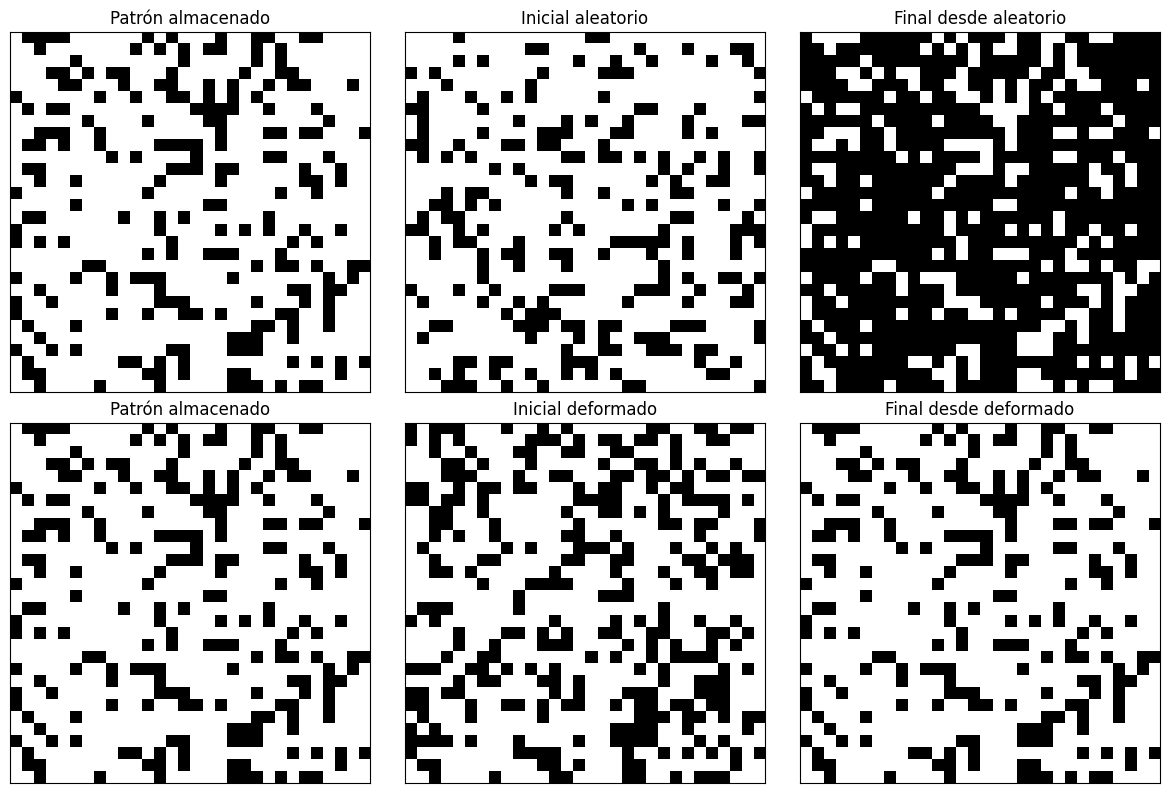

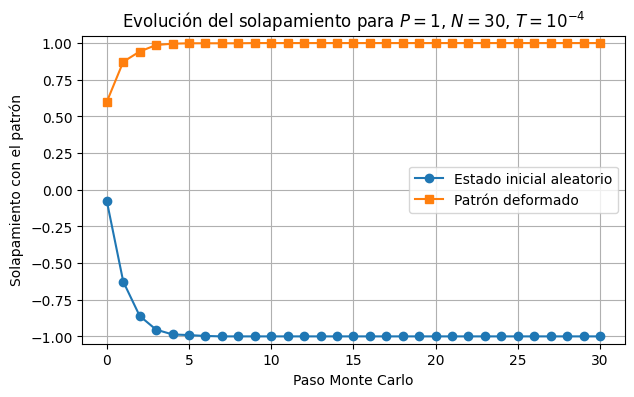

========== RESULTADOS ==========
N = 30
P = 1
T = 0.0001
Número de pasos Monte Carlo = 30

Caso inicial aleatorio:
Solapamiento inicial = -0.077
Solapamiento final   = -1.000
Energía inicial      = -0.502
Energía final        = -84.124

Caso patrón deformado:
Solapamiento inicial = 0.599
Solapamiento final   = 1.000
Energía inicial      = -30.225
Energía final        = -84.124


In [12]:
# ============================================================
# RESULTADOS 1: RECUPERACIÓN DE UN ÚNICO PATRÓN
# ============================================================

# --------------------------
# Parámetros del experimento
# --------------------------

rng = crear_rng(seed=123)

N = 30
P = 1
prob_activa = 0.25
T = 1e-4
num_pasos_mc = 30
fraccion_ruido = 0.2

# --------------------------
# Generación del patrón
# --------------------------

patrones = np.array([
    crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
    for _ in range(P)
])

patron_objetivo = patrones[0]

# --------------------------
# Cálculo de pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

print(f"Bias del patrón: a = {a:.3f}")

# ============================================================
# CASO (i): ESTADO INICIAL ALEATORIO
# ============================================================

estado_inicial_aleatorio = crear_patron_aleatorio(
    N,
    prob_activa=prob_activa,
    rng=rng
)

estado_final_aleatorio, energias_aleatorio, aceptaciones_aleatorio, solapamientos_aleatorio = evolucionar_red_con_solapamiento(
    estado_inicial=estado_inicial_aleatorio,
    pesos=pesos,
    umbrales=umbrales,
    patrones=patrones,
    T=T,
    num_pasos_mc=num_pasos_mc,
    rng=rng
)

# ============================================================
# CASO (ii): PATRÓN DEFORMADO
# ============================================================

estado_inicial_deformado = deformar_patron(
    patron_objetivo,
    fraccion_ruido=fraccion_ruido,
    rng=rng
)

estado_final_deformado, energias_deformado, aceptaciones_deformado, solapamientos_deformado = evolucionar_red_con_solapamiento(
    estado_inicial=estado_inicial_deformado,
    pesos=pesos,
    umbrales=umbrales,
    patrones=patrones,
    T=T,
    num_pasos_mc=num_pasos_mc,
    rng=rng
)

# ============================================================
# REPRESENTACIÓN DE LOS ESTADOS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Caso aleatorio
axes[0, 0].imshow(patron_objetivo, cmap="gray_r")
axes[0, 0].set_title("Patrón almacenado")

axes[0, 1].imshow(estado_inicial_aleatorio, cmap="gray_r")
axes[0, 1].set_title("Inicial aleatorio")

axes[0, 2].imshow(estado_final_aleatorio, cmap="gray_r")
axes[0, 2].set_title("Final desde aleatorio")

# Caso deformado
axes[1, 0].imshow(patron_objetivo, cmap="gray_r")
axes[1, 0].set_title("Patrón almacenado")

axes[1, 1].imshow(estado_inicial_deformado, cmap="gray_r")
axes[1, 1].set_title("Inicial deformado")

axes[1, 2].imshow(estado_final_deformado, cmap="gray_r")
axes[1, 2].set_title("Final desde deformado")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# ============================================================
# SOLAPAMIENTO EN FUNCIÓN DEL TIEMPO
# ============================================================

tiempos = np.arange(num_pasos_mc + 1)

plt.figure(figsize=(7, 4))

plt.plot(
    tiempos,
    solapamientos_aleatorio[:, 0],
    marker="o",
    label="Estado inicial aleatorio"
)

plt.plot(
    tiempos,
    solapamientos_deformado[:, 0],
    marker="s",
    label="Patrón deformado"
)

plt.xlabel("Paso Monte Carlo")
plt.ylabel("Solapamiento con el patrón")
plt.title(r"Evolución del solapamiento para $P=1$, $N=30$, $T=10^{-4}$")
plt.ylim(-1.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

print("========== RESULTADOS ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"T = {T}")
print(f"Número de pasos Monte Carlo = {num_pasos_mc}")
print()

print("Caso inicial aleatorio:")
print(f"Solapamiento inicial = {solapamientos_aleatorio[0, 0]:.3f}")
print(f"Solapamiento final   = {solapamientos_aleatorio[-1, 0]:.3f}")
print(f"Energía inicial      = {energias_aleatorio[0]:.3f}")
print(f"Energía final        = {energias_aleatorio[-1]:.3f}")
print()

print("Caso patrón deformado:")
print(f"Solapamiento inicial = {solapamientos_deformado[0, 0]:.3f}")
print(f"Solapamiento final   = {solapamientos_deformado[-1, 0]:.3f}")
print(f"Energía inicial      = {energias_deformado[0]:.3f}")
print(f"Energía final        = {energias_deformado[-1]:.3f}")

## 4.2 Curva de solapamiento frente a temperatura

Se han realizado varias repeticiones para cada temperatura a partir de un patrón deformado, de forma que se pueda estudiar el solapamiento final frente a la temperatura. El solapamiento se ha calculado como media de 8 valores con su error correspondiente(vease la gráfica mas abajo, así como los valores exactos y condiciones iniciales).

Como era de esperar se observa que la dispersión de resultados aumenta en el régimen intermedio de temperaturas, indicando una transición entre un estado ordenado, donde la red recupera el patrón, y un estado desordenado donde la memoria se pierde. Para valores bajos de $T$, el sistema presenta un comportamiento prácticamente determinista, en el que la dinámica está dominada por la minimización de la energía. A medida que la temperatura aumenta, se comienzan a aceptar cambios energéticamente desfavorables, la probabilidad de aceptar un paso montecarlo aumenta. En el régimen de temperaturas intermedias se observa un aumento de la dispersión de los resultados, reflejado en las barras de error. Finalmente en el regimen te temperaturas muy altas, se tiende a un estado completamente desordenado sin correlación con el patron original.

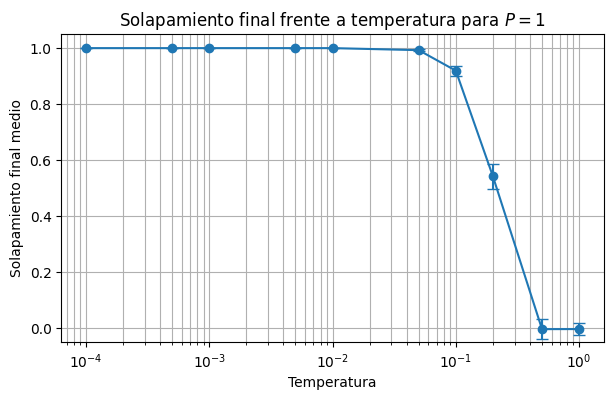

========== ESTUDIO EN TEMPERATURA ==========
N = 30
P = 1
Pasos Monte Carlo = 50
Repeticiones por temperatura = 8
Fracción de ruido inicial = 0.2
Bias del patrón = 0.256

T = 0.0001  |  <m_final> = 1.000 ± 0.000
T = 0.0005  |  <m_final> = 1.000 ± 0.000
T = 0.001  |  <m_final> = 1.000 ± 0.000
T = 0.005  |  <m_final> = 1.000 ± 0.000
T = 0.01  |  <m_final> = 1.000 ± 0.000
T = 0.05  |  <m_final> = 0.993 ± 0.004
T = 0.1  |  <m_final> = 0.919 ± 0.018
T = 0.2  |  <m_final> = 0.542 ± 0.044
T = 0.5  |  <m_final> = -0.004 ± 0.035
T = 1  |  <m_final> = -0.003 ± 0.021


In [13]:
# ============================================================
# RESULTADOS 2: SOLAPAMIENTO FINAL FRENTE A TEMPERATURA
# ============================================================

rng = crear_rng(seed=456)

# --------------------------
# Parámetros del experimento
# --------------------------

N = 30
P = 1
prob_activa = 0.25
fraccion_ruido = 0.2
num_pasos_mc = 50
num_repeticiones = 8

temperaturas = np.array([
    1e-4, 5e-4,
    1e-3, 5e-3,
    1e-2, 5e-2,
    1e-1, 2e-1,
    5e-1, 1.0
])

# --------------------------
# Generación de patrón
# --------------------------

patrones = np.array([
    crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
    for _ in range(P)
])

patron_objetivo = patrones[0]

# --------------------------
# Pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

# --------------------------
# Estudio en temperatura
# --------------------------

solapamientos_medios, solapamientos_std = estudiar_temperaturas(
    patron_objetivo=patron_objetivo,
    patrones=patrones,
    pesos=pesos,
    umbrales=umbrales,
    temperaturas=temperaturas,
    fraccion_ruido=fraccion_ruido,
    num_pasos_mc=num_pasos_mc,
    num_repeticiones=num_repeticiones,
    rng=rng
)

# --------------------------
# Representación
# --------------------------

plt.figure(figsize=(7, 4))

plt.errorbar(
    temperaturas,
    solapamientos_medios,
    yerr=solapamientos_std,
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("Temperatura")
plt.ylabel("Solapamiento final medio")
plt.title(r"Solapamiento final frente a temperatura para $P=1$")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both")
plt.show()

# --------------------------
# Resultados numéricos
# --------------------------

print("========== ESTUDIO EN TEMPERATURA ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"Pasos Monte Carlo = {num_pasos_mc}")
print(f"Repeticiones por temperatura = {num_repeticiones}")
print(f"Fracción de ruido inicial = {fraccion_ruido}")
print(f"Bias del patrón = {a:.3f}")
print()

for T, m, dm in zip(temperaturas, solapamientos_medios, solapamientos_std):
    print(f"T = {T:.4g}  |  <m_final> = {m:.3f} ± {dm:.3f}")

## 4.3 Estudio del modelo con varios patrones memorizados.
### 4.3.1 Capacidad de recordar un patrón entre 10 aleatorios memorizados

Se trata de estudiar la capacidad de recordar un patron a partir teniendo 10 patrones memorizados. A partir del primer patrón deformado, se ve cláramente como se llega al solapamiento $m_1 = 1$ rápidamente. Ya veremos en la siguiente sección la cantidad de patrones que se pueden memorizar y seguir obteniendo el patrón deformado correctamente(teniendo en cuenta como de deformado está este, es decir, el ruido imputesto).

Sin embargo a partir de un patrón aleatorio, no tenemos a priori, porque obtener el primer patrón con mas probabilidad que otros, además, como en el ejemplo mostrado más adelante podemos observar que es más fácil llegar a un estado espúreo. Esto se debe a que partimos de un patrón mezcla de todos, siendo más probable llegar a un metaequilibrio, que en el caso del patrón deformado.


Bias medio de los patrones: a = 0.250


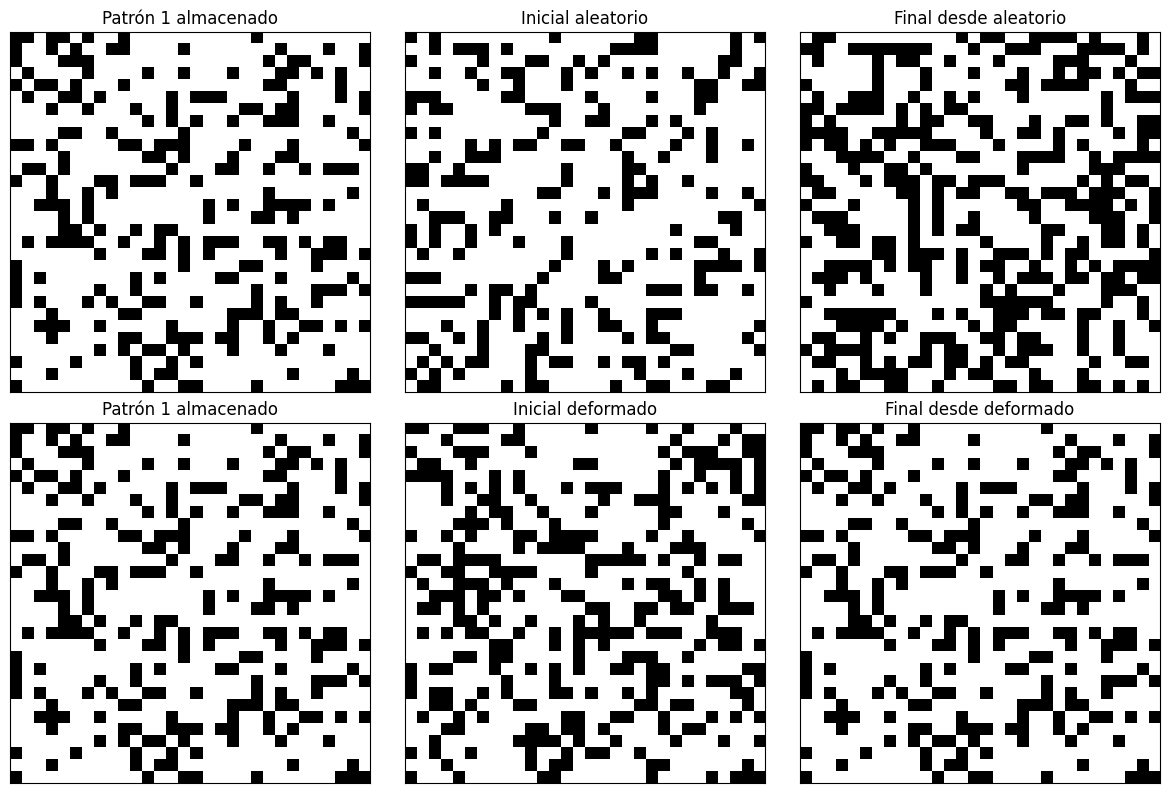

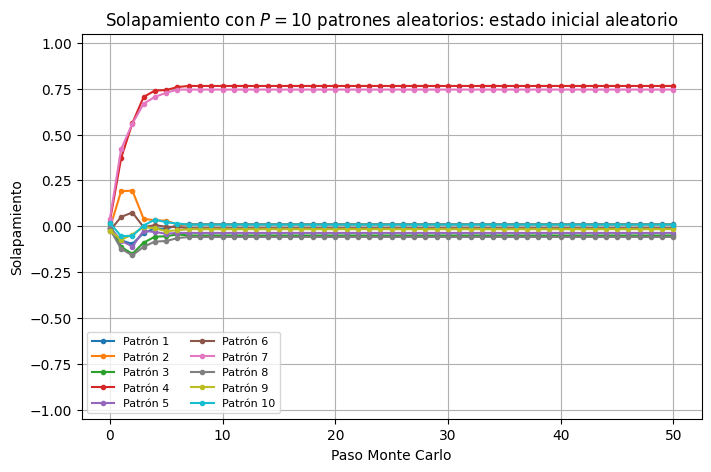

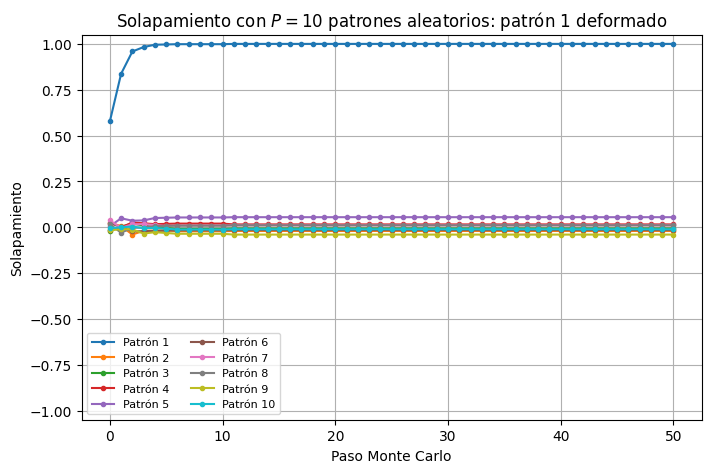

========== VARIOS PATRONES ALEATORIOS ==========
N = 30
P = 10
T = 0.0001
Pasos Monte Carlo = 50
Fracción de ruido inicial = 0.2

Caso inicial aleatorio:
m_1 final = 0.011
m_2 final = 0.009
m_3 final = -0.050
m_4 final = 0.765
m_5 final = -0.036
m_6 final = -0.011
m_7 final = 0.745
m_8 final = -0.059
m_9 final = -0.016
m_10 final = 0.009

Caso patrón 1 deformado:
m_1 final = 1.000
m_2 final = -0.021
m_3 final = -0.007
m_4 final = 0.015
m_5 final = 0.055
m_6 final = -0.016
m_7 final = 0.010
m_8 final = 0.010
m_9 final = -0.040
m_10 final = -0.011


In [14]:
# ============================================================
# RESULTADOS 3.1: VARIOS PATRONES ALEATORIOS
# Solapamiento en función del tiempo
# ============================================================

rng = crear_rng(seed=789)

# --------------------------
# Parámetros
# --------------------------

N = 30
P = 10
prob_activa = 0.25
T = 1e-4
num_pasos_mc = 50
fraccion_ruido = 0.2

# --------------------------
# Generación de patrones aleatorios
# --------------------------

patrones = np.array([
    crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
    for _ in range(P)
])

patron_objetivo = patrones[0]

# --------------------------
# Pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

print(f"Bias medio de los patrones: a = {a:.3f}")

# ============================================================
# CASO (i): ESTADO INICIAL ALEATORIO
# ============================================================

estado_inicial_aleatorio = crear_patron_aleatorio(
    N,
    prob_activa=prob_activa,
    rng=rng
)

estado_final_aleatorio, energias_aleatorio, aceptaciones_aleatorio, solapamientos_aleatorio = evolucionar_red_con_solapamiento(
    estado_inicial=estado_inicial_aleatorio,
    pesos=pesos,
    umbrales=umbrales,
    patrones=patrones,
    T=T,
    num_pasos_mc=num_pasos_mc,
    rng=rng
)

# ============================================================
# CASO (ii): PATRÓN 1 DEFORMADO
# ============================================================

estado_inicial_deformado = deformar_patron(
    patron_objetivo,
    fraccion_ruido=fraccion_ruido,
    rng=rng
)

estado_final_deformado, energias_deformado, aceptaciones_deformado, solapamientos_deformado = evolucionar_red_con_solapamiento(
    estado_inicial=estado_inicial_deformado,
    pesos=pesos,
    umbrales=umbrales,
    patrones=patrones,
    T=T,
    num_pasos_mc=num_pasos_mc,
    rng=rng
)

# ============================================================
# REPRESENTACIÓN DE ESTADOS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(patron_objetivo, cmap="gray_r")
axes[0, 0].set_title("Patrón 1 almacenado")

axes[0, 1].imshow(estado_inicial_aleatorio, cmap="gray_r")
axes[0, 1].set_title("Inicial aleatorio")

axes[0, 2].imshow(estado_final_aleatorio, cmap="gray_r")
axes[0, 2].set_title("Final desde aleatorio")

axes[1, 0].imshow(patron_objetivo, cmap="gray_r")
axes[1, 0].set_title("Patrón 1 almacenado")

axes[1, 1].imshow(estado_inicial_deformado, cmap="gray_r")
axes[1, 1].set_title("Inicial deformado")

axes[1, 2].imshow(estado_final_deformado, cmap="gray_r")
axes[1, 2].set_title("Final desde deformado")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# ============================================================
# SOLAPAMIENTOS EN FUNCIÓN DEL TIEMPO
# ============================================================

tiempos = np.arange(num_pasos_mc + 1)

# Caso aleatorio
plt.figure(figsize=(8, 5))

for mu in range(P):
    plt.plot(
        tiempos,
        solapamientos_aleatorio[:, mu],
        marker="o",
        markersize=3,
        label=f"Patrón {mu+1}"
    )

plt.xlabel("Paso Monte Carlo")
plt.ylabel("Solapamiento")
plt.title(r"Solapamiento con $P=10$ patrones aleatorios: estado inicial aleatorio")
plt.ylim(-1.05, 1.05)
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

# Caso deformado
plt.figure(figsize=(8, 5))

for mu in range(P):
    plt.plot(
        tiempos,
        solapamientos_deformado[:, mu],
        marker="o",
        markersize=3,
        label=f"Patrón {mu+1}"
    )

plt.xlabel("Paso Monte Carlo")
plt.ylabel("Solapamiento")
plt.title(r"Solapamiento con $P=10$ patrones aleatorios: patrón 1 deformado")
plt.ylim(-1.05, 1.05)
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

print("========== VARIOS PATRONES ALEATORIOS ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"T = {T}")
print(f"Pasos Monte Carlo = {num_pasos_mc}")
print(f"Fracción de ruido inicial = {fraccion_ruido}")
print()

print("Caso inicial aleatorio:")
for i in range(P):
    print(f"m_{i+1} final = {solapamientos_aleatorio[-1, i]:.3f}")

print()

print("Caso patrón 1 deformado:")
for i in range(P):
    print(f"m_{i+1} final = {solapamientos_deformado[-1, i]:.3f}")

### 4.3.2 Solapamiento en función de la temperatura de un patrón deformado de uno de 10 patrones aleatorios

Esta vez se observa como el solapamiento final decae mas rápidamente con la temperatura que en el caso de la cantidad de patrones $P=1$. Esto se debe cláramente a que a mayor cantidad de patrones recordados, será más dificil llegar a un patrón concreto, esto se estudiará más en profundidad en la siguiente sección. Es importante destacar que estamos deformando un $20$% del del patrón deformado.


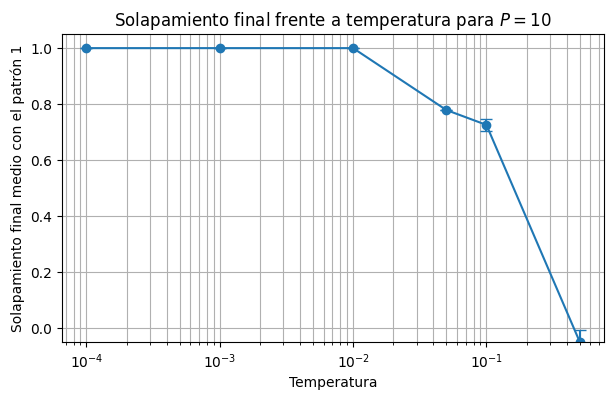

========== ESTUDIO EN TEMPERATURA CON P = 10 ==========
N = 30
P = 10
Pasos Monte Carlo = 40
Repeticiones por temperatura = 4
Fracción de ruido inicial = 0.2
Bias medio = 0.241

T = 0.0001  |  <m_final> = 1.000 ± 0.000
T = 0.001  |  <m_final> = 1.000 ± 0.000
T = 0.01  |  <m_final> = 1.000 ± 0.000
T = 0.05  |  <m_final> = 0.779 ± 0.001
T = 0.1  |  <m_final> = 0.726 ± 0.021
T = 0.5  |  <m_final> = -0.048 ± 0.041


In [15]:
# ============================================================
# RESULTADOS 3.2: SOLAPAMIENTO FINAL FRENTE A TEMPERATURA
# CON P = 10 PATRONES ALEATORIOS
# Solo caso: patrón 1 deformado
# ============================================================

rng = crear_rng(seed=987)

# --------------------------
# Parámetros
# --------------------------

N = 30
P = 10
prob_activa = 0.25
fraccion_ruido = 0.2
num_pasos_mc = 40
num_repeticiones = 4

temperaturas = np.array([
    1e-4,
    1e-3,
    1e-2,
    5e-2,
    1e-1,
    5e-1
])

# --------------------------
# Generación de patrones
# --------------------------

patrones = np.array([
    crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
    for _ in range(P)
])

patron_objetivo = patrones[0]

# --------------------------
# Pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

# --------------------------
# Estudio en temperatura
# --------------------------

solapamientos_medios = []
solapamientos_std = []

for T in temperaturas:

    solapamientos_T = []

    for _ in range(num_repeticiones):

        estado_inicial = deformar_patron(
            patron_objetivo,
            fraccion_ruido=fraccion_ruido,
            rng=rng
        )

        _, _, _, solapamientos = evolucionar_red_con_solapamiento(
            estado_inicial=estado_inicial,
            pesos=pesos,
            umbrales=umbrales,
            patrones=patrones,
            T=T,
            num_pasos_mc=num_pasos_mc,
            rng=rng
        )

        # Solapamiento final con el patrón objetivo
        solapamientos_T.append(solapamientos[-1, 0])

    solapamientos_medios.append(np.mean(solapamientos_T))
    solapamientos_std.append(np.std(solapamientos_T))

solapamientos_medios = np.array(solapamientos_medios)
solapamientos_std = np.array(solapamientos_std)

# --------------------------
# Representación
# --------------------------

plt.figure(figsize=(7, 4))

plt.errorbar(
    temperaturas,
    solapamientos_medios,
    yerr=solapamientos_std,
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("Temperatura")
plt.ylabel("Solapamiento final medio con el patrón 1")
plt.title(r"Solapamiento final frente a temperatura para $P=10$")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both")
plt.show()

# --------------------------
# Resultados numéricos
# --------------------------

print("========== ESTUDIO EN TEMPERATURA CON P = 10 ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"Pasos Monte Carlo = {num_pasos_mc}")
print(f"Repeticiones por temperatura = {num_repeticiones}")
print(f"Fracción de ruido inicial = {fraccion_ruido}")
print(f"Bias medio = {a:.3f}")
print()

for T, m, dm in zip(temperaturas, solapamientos_medios, solapamientos_std):
    print(f"T = {T:.4g}  |  <m_final> = {m:.3f} ± {dm:.3f}")

### 4.3.3 Capacidad de recordar el patrón 0 entre los numeros del 0 al 9

Podemos observar en las siguientes gráficas, que no se ha llegado a memorizar completamente el patron del número 0, ni siquiera partiendo de una deformación de este. Además se ha llegado a un patrón en este caso, y a su antipatrón desde el aleatorio. A partir de esto podemos deducir que dicho patrón, que corresponde con el número 8 es mucho mas accesible y estable(minimiza la energía) que el resto de patrones. Esto último se puede explicar sencillamente porque el 8 es el número que mayor solapamiento comparte con el resto de numeros. Y por tanto, el más favorable en cada paso montecarlo.

A partir de este ejemplo más concreto y familiar, se visualizan las limitaciones de este modelo, que funciona mejor cuanto menos solapados esten unos patrones de otros. De hecho, se puede deducir fácilmente del modelo utilizado, que los patrones menos solapados con otros, son los mas accesibles a partir de un patrón deformado de estos. Esto se debe a que la "cuenca", a partir de la cual este patrón es más favorable o probable es mayor. Puesto que más dificilmente se accede a otros patrones(estamos más lejos de estos otros).

Bias medio: a = 0.207


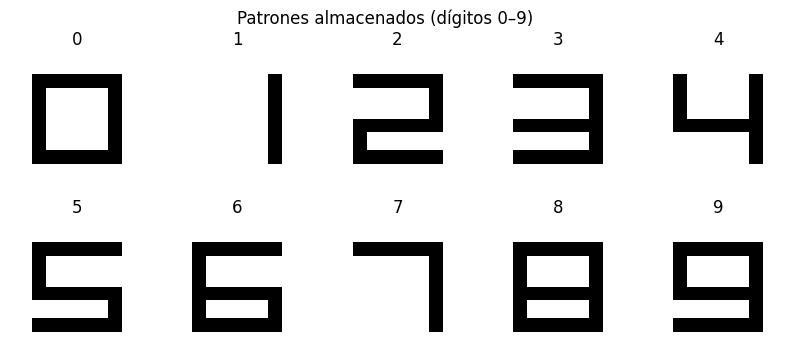

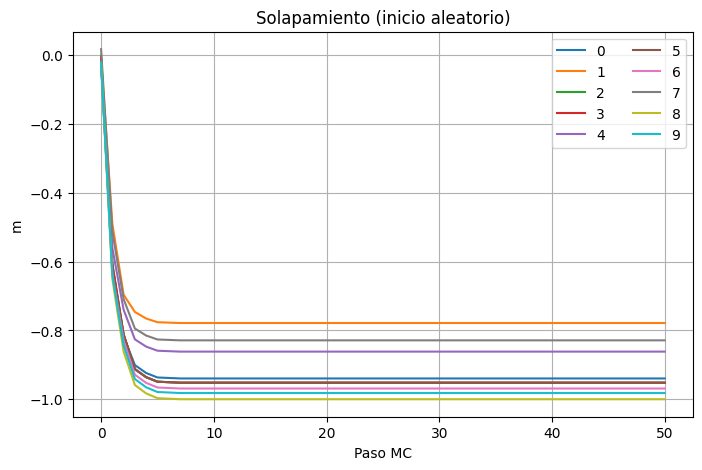

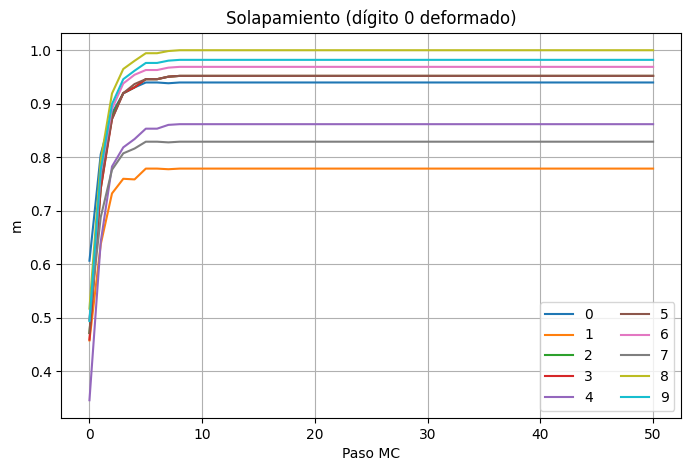

In [17]:
# ============================================================
# RESULTADOS 3.3: DÍGITOS 0–9
# Solapamiento en función del tiempo
# ============================================================

rng = crear_rng(seed=321)

# --------------------------
# Parámetros
# --------------------------

N = 30
P = 10
T = 1e-4
num_pasos_mc = 50
fraccion_ruido = 0.2

# ============================================================
# FUNCIÓN PARA CREAR DÍGITOS SIMPLES
# ============================================================

def crear_digito(digito, N):
    img = np.zeros((N, N))

    m = N // 6
    n = N - m
    grosor = N // 15 + 1

    def hline(y):
        img[y:y+grosor, m:n] = 1

    def vline_izq(y1, y2):
        img[y1:y2, m:m+grosor] = 1

    def vline_der(y1, y2):
        img[y1:y2, n-grosor:n] = 1

    # --------------------------
    # DÍGITOS CORREGIDOS
    # --------------------------

    if digito == 0:
        hline(m); hline(n-grosor)
        vline_izq(m, n); vline_der(m, n)

    elif digito == 1:
        vline_der(m, n)

    elif digito == 2:
        hline(m)
        vline_der(m, N//2)
        hline(N//2)
        vline_izq(N//2, n)
        hline(n-grosor)

    elif digito == 3:
        hline(m)
        vline_der(m, n)
        hline(N//2)
        hline(n-grosor)

    elif digito == 4:
        vline_izq(m, N//2)
        vline_der(m, n)
        hline(N//2)

    elif digito == 5:
        hline(m)
        vline_izq(m, N//2)
        hline(N//2)
        vline_der(N//2, n)
        hline(n-grosor)

    elif digito == 6:
        hline(m)
        vline_izq(m, n)
        hline(N//2)
        vline_der(N//2, n)
        hline(n-grosor)

    elif digito == 7:
        hline(m)
        vline_der(m, n)

    elif digito == 8:
        hline(m); hline(N//2); hline(n-grosor)
        vline_izq(m, n); vline_der(m, n)

    elif digito == 9:
        hline(m)
        vline_izq(m, N//2)
        vline_der(m, n)
        hline(N//2)
        hline(n-grosor)

    return img.astype(int)

# --------------------------
# Generar patrones 0–9
# --------------------------

patrones = np.array([
    crear_digito(d, N)
    for d in range(10)
])

patron_objetivo = patrones[0]  # dígito 0

# --------------------------
# Pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

print(f"Bias medio: a = {a:.3f}")

# ============================================================
# CASO (i): ESTADO INICIAL ALEATORIO
# ============================================================

estado_inicial_aleatorio = crear_patron_aleatorio(N, prob_activa=0.25, rng=rng)

_, _, _, solapamientos_aleatorio = evolucionar_red_con_solapamiento(
    estado_inicial_aleatorio,
    pesos,
    umbrales,
    patrones,
    T,
    num_pasos_mc,
    rng
)

# ============================================================
# CASO (ii): DÍGITO DEFORMADO
# ============================================================

estado_inicial_deformado = deformar_patron(
    patron_objetivo,
    fraccion_ruido=fraccion_ruido,
    rng=rng
)

_, _, _, solapamientos_deformado = evolucionar_red_con_solapamiento(
    estado_inicial_deformado,
    pesos,
    umbrales,
    patrones,
    T,
    num_pasos_mc,
    rng
)

# ============================================================
# REPRESENTACIÓN DE LOS PATRONES
# ============================================================

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(patrones[i], cmap="gray_r")
    plt.title(f"{i}")
    plt.axis("off")
plt.suptitle("Patrones almacenados (dígitos 0–9)")
plt.show()

# ============================================================
# SOLAPAMIENTO EN FUNCIÓN DEL TIEMPO
# ============================================================

tiempos = np.arange(num_pasos_mc + 1)

# Caso aleatorio
plt.figure(figsize=(8,5))
for mu in range(10):
    plt.plot(tiempos, solapamientos_aleatorio[:, mu], label=f"{mu}")
plt.title("Solapamiento (inicio aleatorio)")
plt.xlabel("Paso MC")
plt.ylabel("m")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# Caso deformado
plt.figure(figsize=(8,5))
for mu in range(10):
    plt.plot(tiempos, solapamientos_deformado[:, mu], label=f"{mu}")
plt.title("Solapamiento (dígito 0 deformado)")
plt.xlabel("Paso MC")
plt.ylabel("m")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

### 4.3.4 Solapamiento frente a temperatura del patron 0 deformado

Se ha representado el solapamiento con el numero 0 de un patron deformado del 0 en función de la temperatura, se puede ver como en este caso, a pesar de recordar 10 patrones, el modelo decae mucho más lentamente con la temperatura comparado con los 10 patrones aleatorios que hemos estudiado anteriormente. Sin embargo nunca llega al solapamiento $m_0 = 1$. Siguiendo con los argumentos del anterior apartado, podemos deducir fácilmente que el patrón al que se ha llegado es al número 8. Y el tan lento decaimiento con la temperatura muestra la increible estabilidad de este patrón. Los motivos han sido ya explicados en el anterior resultado.

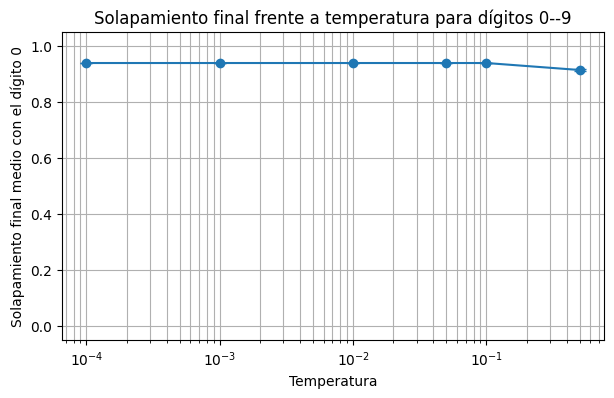

========== ESTUDIO EN TEMPERATURA CON DÍGITOS 0–9 ==========
N = 30
P = 10
Pasos Monte Carlo = 40
Repeticiones por temperatura = 4
Fracción de ruido inicial = 0.2
Bias medio = 0.207

T = 0.0001  |  <m_final dígito 0> = 0.940 ± 0.000
T = 0.001  |  <m_final dígito 0> = 0.940 ± 0.000
T = 0.01  |  <m_final dígito 0> = 0.940 ± 0.000
T = 0.05  |  <m_final dígito 0> = 0.940 ± 0.000
T = 0.1  |  <m_final dígito 0> = 0.940 ± 0.000
T = 0.5  |  <m_final dígito 0> = 0.915 ± 0.004


In [18]:
# ============================================================
# RESULTADOS 3.4: SOLAPAMIENTO FINAL FRENTE A TEMPERATURA
# CON PATRONES 0–9
# Solo caso: dígito 0 deformado
# ============================================================

rng = crear_rng(seed=654)

# --------------------------
# Parámetros
# --------------------------

N = 30
P = 10
fraccion_ruido = 0.2
num_pasos_mc = 40
num_repeticiones = 4

temperaturas = np.array([
    1e-4,
    1e-3,
    1e-2,
    5e-2,
    1e-1,
    5e-1
])

# --------------------------
# Generación de patrones: dígitos 0–9
# --------------------------

patrones = np.array([
    crear_digito(d, N)
    for d in range(10)
])

patron_objetivo = patrones[0]  # dígito 0

# --------------------------
# Pesos y umbrales
# --------------------------

pesos, a = calcular_pesos(patrones)
umbrales = calcular_umbrales(pesos)

# --------------------------
# Estudio en temperatura
# --------------------------

solapamientos_medios = []
solapamientos_std = []

for T in temperaturas:

    solapamientos_T = []

    for _ in range(num_repeticiones):

        estado_inicial = deformar_patron(
            patron_objetivo,
            fraccion_ruido=fraccion_ruido,
            rng=rng
        )

        _, _, _, solapamientos = evolucionar_red_con_solapamiento(
            estado_inicial=estado_inicial,
            pesos=pesos,
            umbrales=umbrales,
            patrones=patrones,
            T=T,
            num_pasos_mc=num_pasos_mc,
            rng=rng
        )

        # Solapamiento final con el dígito 0
        solapamientos_T.append(solapamientos[-1, 0])

    solapamientos_medios.append(np.mean(solapamientos_T))
    solapamientos_std.append(np.std(solapamientos_T))

solapamientos_medios = np.array(solapamientos_medios)
solapamientos_std = np.array(solapamientos_std)

# --------------------------
# Representación
# --------------------------

plt.figure(figsize=(7, 4))

plt.errorbar(
    temperaturas,
    solapamientos_medios,
    yerr=solapamientos_std,
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("Temperatura")
plt.ylabel("Solapamiento final medio con el dígito 0")
plt.title(r"Solapamiento final frente a temperatura para dígitos 0--9")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both")
plt.show()

# --------------------------
# Resultados numéricos
# --------------------------

print("========== ESTUDIO EN TEMPERATURA CON DÍGITOS 0–9 ==========")
print(f"N = {N}")
print(f"P = {P}")
print(f"Pasos Monte Carlo = {num_pasos_mc}")
print(f"Repeticiones por temperatura = {num_repeticiones}")
print(f"Fracción de ruido inicial = {fraccion_ruido}")
print(f"Bias medio = {a:.3f}")
print()

for T, m, dm in zip(temperaturas, solapamientos_medios, solapamientos_std):
    print(f"T = {T:.4g}  |  <m_final dígito 0> = {m:.3f} ± {dm:.3f}")

## 4.4 Estudio del modelo en función de la cantidad de patrones memorizados(P)

### 4.4.1 Disminución de patrones recordados en función de P

Se ha estudiado como disminuye la capacidad de recordar patrones a partir del mismo patrón deformado con un $20$% de ruido en función de la cantida de patrones memorizados. Es importante tener en cuenta que se considera que se ha recordado un patrón si el solapamiento final de este patrón $m_i > 0.75$.

Así pues, podemos observar, como era de esperar, como decae dicha memoria a mayor $P$. Se han barrido valores de $P$ de 5 en 5. En la primera gráfica se observa como ya con $P = 10$ no se ha logrado recordar uno de los 10 patrones y como para $P = 35$ no se ha logrado recordar ninguno de los 35 patrones.

Cabe destacar que puesto que los patrones son aleatorios y diferentes en cada ejecución, los resultados no son fijos.

Calculando P = 1...
Calculando P = 5...
Calculando P = 10...
Calculando P = 15...
Calculando P = 20...
Calculando P = 25...
Calculando P = 30...
Calculando P = 35...
Calculando P = 40...


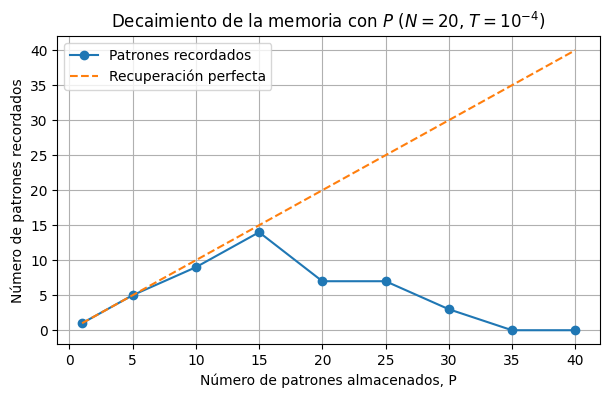

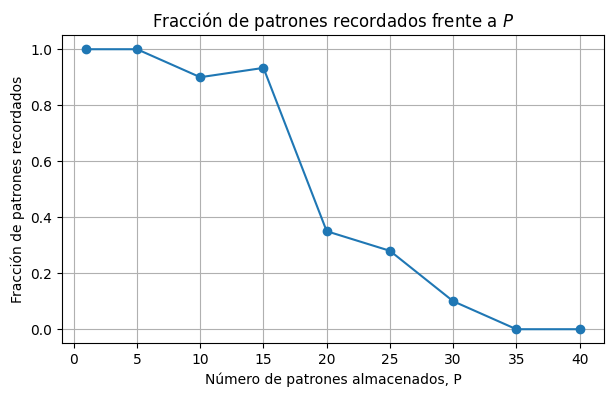

========== DECAIMIENTO DE LA MEMORIA ==========
N = 20
T = 0.0001
Pasos Monte Carlo = 30
Fracción de ruido inicial = 0.2
Umbral de recuerdo = 0.75

P =  1 | recordados =  1/ 1 | fracción = 1.00
P =  5 | recordados =  5/ 5 | fracción = 1.00
P = 10 | recordados =  9/10 | fracción = 0.90
P = 15 | recordados = 14/15 | fracción = 0.93
P = 20 | recordados =  7/20 | fracción = 0.35
P = 25 | recordados =  7/25 | fracción = 0.28
P = 30 | recordados =  3/30 | fracción = 0.10
P = 35 | recordados =  0/35 | fracción = 0.00
P = 40 | recordados =  0/40 | fracción = 0.00


In [19]:
# ============================================================
# RESULTADOS 4.1: DECAIMIENTO DE LA MEMORIA CON P
# Barrido grueso
# ============================================================

rng = crear_rng(seed=111)

# --------------------------
# Parámetros
# --------------------------

N = 20
T = 1e-4
prob_activa = 0.25
fraccion_ruido = 0.2
num_pasos_mc = 30
umbral_recuerdo = 0.75

valores_P = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40])

patrones_recordados = []
fraccion_recordada = []

# --------------------------
# Barrido en P
# --------------------------

for P in valores_P:

    print(f"Calculando P = {P}...")

    # Generar P patrones aleatorios
    patrones = np.array([
        crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
        for _ in range(P)
    ])

    # Construir pesos y umbrales
    pesos, a = calcular_pesos(patrones)
    umbrales = calcular_umbrales(pesos)

    contador_recordados = 0

    # Probar recuperación de cada patrón
    for mu in range(P):

        patron_objetivo = patrones[mu]

        estado_inicial = deformar_patron(
            patron_objetivo,
            fraccion_ruido=fraccion_ruido,
            rng=rng
        )

        _, _, _, solapamientos = evolucionar_red_con_solapamiento(
            estado_inicial=estado_inicial,
            pesos=pesos,
            umbrales=umbrales,
            patrones=patrones,
            T=T,
            num_pasos_mc=num_pasos_mc,
            rng=rng
        )

        solapamiento_final = solapamientos[-1, mu]

        if solapamiento_final > umbral_recuerdo:
            contador_recordados += 1

    patrones_recordados.append(contador_recordados)
    fraccion_recordada.append(contador_recordados / P)

patrones_recordados = np.array(patrones_recordados)
fraccion_recordada = np.array(fraccion_recordada)

# --------------------------
# Representación: número de patrones recordados
# --------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    valores_P,
    patrones_recordados,
    marker="o",
    label="Patrones recordados"
)

plt.plot(
    valores_P,
    valores_P,
    linestyle="--",
    label="Recuperación perfecta"
)

plt.xlabel("Número de patrones almacenados, P")
plt.ylabel("Número de patrones recordados")
plt.title(r"Decaimiento de la memoria con $P$ ($N=20$, $T=10^{-4}$)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------
# Representación: fracción recordada
# --------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    valores_P,
    fraccion_recordada,
    marker="o"
)

plt.xlabel("Número de patrones almacenados, P")
plt.ylabel("Fracción de patrones recordados")
plt.title(r"Fracción de patrones recordados frente a $P$")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.show()

# --------------------------
# Resultados numéricos
# --------------------------

print("========== DECAIMIENTO DE LA MEMORIA ==========")
print(f"N = {N}")
print(f"T = {T}")
print(f"Pasos Monte Carlo = {num_pasos_mc}")
print(f"Fracción de ruido inicial = {fraccion_ruido}")
print(f"Umbral de recuerdo = {umbral_recuerdo}")
print()

for P, rec, frac in zip(valores_P, patrones_recordados, fraccion_recordada):
    print(f"P = {P:2d} | recordados = {rec:2d}/{P:2d} | fracción = {frac:.2f}")

### 4.4.2 Fracción máxima de patrones recordables.

En esta subseccion se va calcular el valor de la fracción máxima de patrones memorizables(con $N=20$) de forma que todos los patrones se recuerden con $m_i > 0.75$. Puesto que se ha observado en el anterior resultado que para $P = 10$ ya no se ha logrado recordar un patrón, comenzaremos barriendo desde $P=5$ hasta que no se logren recordar todos los patrones, en este caso $P_c = P_{fallido} - 1$  y  $\alpha_c = P_c/20^2$. Haremos este procedimiento 5 veces y calcularemos una media de los $P_c$ para estimar mejor el valor de $\alpha_c$. Ya que este cambia en cada ejecución.

De esta forma se ha obtenido que $\bar P_c = 9.80 ± 0.40$ y por tanto $\bar \alpha_c = 0.0245 ± 0.0010$. La cantidad de patrones recordados es bastante pequeña, sin embargo esta puede mejorar de diferentes formas. La más importante es $N$, a mayor cantidad de neuronas la capacidad de memoria es mejor. Adicionalmente se pueden ajustar el bias y la temperatura de forma que se memorice mejor.



In [20]:
# ============================================================
# RESULTADOS 4.2: ESTIMACIÓN DE Pc Y alpha_c
# ============================================================

# --------------------------
# Parámetros
# --------------------------

N = 20
T = 1e-4
prob_activa = 0.25
fraccion_ruido = 0.2
num_pasos_mc = 30
umbral_recuerdo = 0.75

P_inicial = 5
P_max = 40
num_estimaciones = 5

Pc_estimados = []
alpha_estimados = []

# --------------------------
# Función auxiliar
# --------------------------

def todos_los_patrones_se_recuerdan(
    P,
    N,
    T,
    prob_activa,
    fraccion_ruido,
    num_pasos_mc,
    umbral_recuerdo,
    rng
):
    """
    Devuelve True si todos los P patrones se recuerdan con m > umbral_recuerdo.
    Devuelve False en cuanto uno falla.
    """

    patrones = np.array([
        crear_patron_aleatorio(N, prob_activa=prob_activa, rng=rng)
        for _ in range(P)
    ])

    pesos, a = calcular_pesos(patrones)
    umbrales = calcular_umbrales(pesos)

    for mu in range(P):

        patron_objetivo = patrones[mu]

        estado_inicial = deformar_patron(
            patron_objetivo,
            fraccion_ruido=fraccion_ruido,
            rng=rng
        )

        _, _, _, solapamientos = evolucionar_red_con_solapamiento(
            estado_inicial=estado_inicial,
            pesos=pesos,
            umbrales=umbrales,
            patrones=patrones,
            T=T,
            num_pasos_mc=num_pasos_mc,
            rng=rng
        )

        solapamiento_final = solapamientos[-1, mu]

        if solapamiento_final <= umbral_recuerdo:
            return False

    return True


# --------------------------
# Estimación de Pc
# --------------------------

for estimacion in range(num_estimaciones):

    rng = crear_rng(seed=1000 + estimacion)

    print(f"\n========== ESTIMACIÓN {estimacion + 1} ==========")

    Pc = P_inicial - 1

    for P in range(P_inicial, P_max + 1):

        print(f"Probando P = {P}...")

        recuerda_todos = todos_los_patrones_se_recuerdan(
            P=P,
            N=N,
            T=T,
            prob_activa=prob_activa,
            fraccion_ruido=fraccion_ruido,
            num_pasos_mc=num_pasos_mc,
            umbral_recuerdo=umbral_recuerdo,
            rng=rng
        )

        if recuerda_todos:
            Pc = P
            print(f"  Todos recordados para P = {P}")
        else:
            print(f"  Fallo para P = {P}. Se detiene esta estimación.")
            break

    alpha_c = Pc / (N * N)

    Pc_estimados.append(Pc)
    alpha_estimados.append(alpha_c)

    print(f"Pc estimado = {Pc}")
    print(f"alpha_c estimado = {alpha_c:.4f}")


# --------------------------
# Resultados finales
# --------------------------

Pc_estimados = np.array(Pc_estimados)
alpha_estimados = np.array(alpha_estimados)

Pc_medio = np.mean(Pc_estimados)
Pc_std = np.std(Pc_estimados)

alpha_medio = np.mean(alpha_estimados)
alpha_std = np.std(alpha_estimados)

print("\n========== RESULTADO FINAL ==========")
print(f"N = {N}")
print(f"N^2 = {N*N}")
print(f"T = {T}")
print(f"Umbral de recuerdo = {umbral_recuerdo}")
print(f"Número de estimaciones = {num_estimaciones}")
print()

print("Pc estimados:", Pc_estimados)
print(f"Pc medio = {Pc_medio:.2f} ± {Pc_std:.2f}")
print()

print("alpha_c estimados:", alpha_estimados)
print(f"alpha_c medio = {alpha_medio:.4f} ± {alpha_std:.4f}")


========== ESTIMACIÓN 1 ==========
Probando P = 5...
  Todos recordados para P = 5
Probando P = 6...
  Todos recordados para P = 6
Probando P = 7...
  Todos recordados para P = 7
Probando P = 8...
  Todos recordados para P = 8
Probando P = 9...
  Todos recordados para P = 9
Probando P = 10...
  Todos recordados para P = 10
Probando P = 11...
  Fallo para P = 11. Se detiene esta estimación.
Pc estimado = 10
alpha_c estimado = 0.0250

========== ESTIMACIÓN 2 ==========
Probando P = 5...
  Todos recordados para P = 5
Probando P = 6...
  Todos recordados para P = 6
Probando P = 7...
  Todos recordados para P = 7
Probando P = 8...
  Todos recordados para P = 8
Probando P = 9...
  Todos recordados para P = 9
Probando P = 10...
  Todos recordados para P = 10
Probando P = 11...
  Fallo para P = 11. Se detiene esta estimación.
Pc estimado = 10
alpha_c estimado = 0.0250

========== ESTIMACIÓN 3 ==========
Probando P = 5...
  Todos recordados para P = 5
Probando P = 6...
  Todos recordados para 

## 5. Conclusiones

En este trabajo se ha estudiado el comportamiento de una red de Hopfield como sistema de memoria asociativa mediante simulaciones Monte Carlo.

Se ha comprobado que la red es capaz de recuperar patrones almacenados a partir de estados iniciales cercanos, siempre que la temperatura sea suficientemente baja. Asimismo, se ha observado que la capacidad de almacenamiento está limitada por la interferencia entre patrones, lo que conduce a la existencia de una capacidad crítica $\alpha_c$.

El análisis de patrones estructurados ha puesto de manifiesto la importancia de las correlaciones entre memorias, favoreciendo estas, la aparición de estados espurios y reduciendo la eficacia del sistema.

En conjunto, el modelo reproduce de forma cualitativa las propiedades esperadas de una memoria asociativa, aunque presenta limitaciones importantes que podrían abordarse mediante el uso de reglas de aprendizaje más avanzadas o representaciones menos correlacionadas.

## Bibliografía

[1] J. J. Hopfield, *Neural networks and physical systems with emergent collective computational abilities*, Proceedings of the National Academy of Sciences, 79(8), 2554–2558 (1982).


[3] D. J. Amit, *Modeling Brain Function: The World of Attractor Neural Networks*, Cambridge University Press (1989).